In [17]:
# Import packages
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [18]:
# Set plotting settings
plt.rcParams['figure.figsize']=(8,8) #rescale figures
sc.settings.verbosity = 3

In [19]:
# Read the adata
adata = sc.read_h5ad('/data/chanjlab/HTA.de_novo_SCLC.010920/out.SCLC.010920/adata.SCLC.010920.h5ad')

In [20]:
adata

AnnData object with n_obs × n_vars = 54313 × 22216
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'mito_frac', 'RBP_frac', 'batch', 'patient', 'tissue', 'treatment', 'procedure', 'SCLC_subtype', 'SCLC_subtype_plus_TP53_RB1_wt', 'pval_SCLC-A', 'pval_SCLC-N', 'pval_SCLC-P', 'NEUROD genes', 'MHCI_PRESENTATION', 'MHCII_PRESENTATION', 'SCLC_major_subtype_of_sample', 'clusters', 'treatment_categorized', 'recurrent_cluster', 'histo', 'clusters_fine'
    var: 'knnDREMI|PLCG2', 'PLCG2_modules', 'AXONOGENESIS', 'NEURON_DIFFERENTIATION', 'NEUROPEPTIDE_RECEPTOR', 'EMT'
    uns: 'diffmap_evals', 'neighbors', 'num_components', 'paga', 'umap', 'var_explained'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    layers: 'imputed_normalized', 'log2(X+0.1)', 'normalized'
    obsp: 'connectivities', 'distances'

In [21]:
adata.obs['SCLC_subtype']

Cell
RU1215_192110488599350                      SCLC-N
RU1152_130751366121844                      SCLC-A
RU1231A_120703424294126                     SCLC-N
RU1322A_LN_133924258008493                  SCLC-P
RU1181B_169649541863334                     SCLC-N
                                             ...  
RU1108a_RPMI_160785132370275                SCLC-A
RU1293A_169220299503989                     SCLC-N
RU1108a_Bambanker_Frozen_231897696155998    SCLC-A
RU1181B_236168014327141                     SCLC-N
RU1145_120772933872502                      SCLC-A
Name: SCLC_subtype, Length: 54313, dtype: category
Categories (3, object): ['SCLC-A', 'SCLC-N', 'SCLC-P']

In [22]:
# Create a DataFrame for plotting
genes_to_plot = ['TMEM173', 'TBK1', 'IRF3']

In [23]:
# Create a DataFrame for plotting
plot_df = pd.DataFrame(index=adata.obs.index)
for gene in genes_to_plot:
    plot_df[gene] = adata.X[:, adata.var.index.values == gene]

In [24]:
# Add additional columns from adata.obs
plot_df['SCLC_subtype'] = adata.obs['SCLC_subtype'].astype(str)

In [25]:
plot_df

,TMEM173,TBK1,IRF3,SCLC_subtype
Cell,,,,
RU1215_192110488599350,0.000000,0.000000,0.000000,SCLC-N
RU1152_130751366121844,0.000000,0.997378,0.583215,SCLC-A
RU1231A_120703424294126,0.000000,1.029073,0.000000,SCLC-N
RU1322A_LN_133924258008493,0.000000,0.708695,1.181834,SCLC-P
RU1181B_169649541863334,1.913711,0.758680,0.758680,SCLC-N
...,...,...,...,...
RU1108a_RPMI_160785132370275,0.000000,0.000000,0.000000,SCLC-A
RU1293A_169220299503989,0.000000,0.000000,1.834053,SCLC-N
RU1108a_Bambanker_Frozen_231897696155998,0.000000,0.890860,1.437527,SCLC-A


In [26]:
# Perform ANOVA test
# Extract data for TMEM173 and SCLC subtype
data = plot_df[['TMEM173', 'SCLC_subtype']]

# Dictionary to store expression data for each subtype
subtype_data = {}

# Group expression data by subtype
for subtype in data['SCLC_subtype'].unique():
    subtype_data[subtype] = data[data['SCLC_subtype'] == subtype]['TMEM173']

# Perform one-way ANOVA
anova_result = stats.f_oneway(*subtype_data.values())

# Print ANOVA result
print("ANOVA p-value:", anova_result.pvalue)

ANOVA p-value: 0.0


In [27]:
# Perform ANOVA test
# Extract data for TBK1 and SCLC subtype
data = plot_df[['TBK1', 'SCLC_subtype']]

# Dictionary to store expression data for each subtype
subtype_data = {}

# Group expression data by subtype
for subtype in data['SCLC_subtype'].unique():
    subtype_data[subtype] = data[data['SCLC_subtype'] == subtype]['TBK1']

# Perform one-way ANOVA
anova_result = stats.f_oneway(*subtype_data.values())

# Print ANOVA result
print("ANOVA p-value:", anova_result.pvalue)

ANOVA p-value: 1.2121198030265792e-186


In [28]:
# Perform ANOVA test
# Extract data for IRF3 and SCLC subtype
data = plot_df[['IRF3', 'SCLC_subtype']]

# Dictionary to store expression data for each subtype
subtype_data = {}

# Group expression data by subtype
for subtype in data['SCLC_subtype'].unique():
    subtype_data[subtype] = data[data['SCLC_subtype'] == subtype]['IRF3']

# Perform one-way ANOVA
anova_result = stats.f_oneway(*subtype_data.values())

# Print ANOVA result
print("ANOVA p-value:", anova_result.pvalue)

ANOVA p-value: 5.25064229395686e-148


In [29]:
# Extract data for genes of interest and SCLC subtype
data = plot_df[['TMEM173', 'TBK1', 'IRF3', 'SCLC_subtype']]

# Dictionary to store ANOVA results for each gene
anova_results = {}

# Group expression data by gene and perform ANOVA for each gene
for gene in ['TMEM173', 'TBK1', 'IRF3']:
    gene_data = {}
    
    # Group expression data by subtype for the current gene
    for subtype in data['SCLC_subtype'].unique():
        gene_data[subtype] = data[data['SCLC_subtype'] == subtype][gene]
    
    # Perform one-way ANOVA for the current gene
    anova_result = stats.f_oneway(*gene_data.values())
    
    # Store ANOVA result in the dictionary
    anova_results[gene] = {
        'F-statistic': anova_result.statistic,
        'p-value': anova_result.pvalue
    }

# Create a DataFrame from ANOVA results
anova_results_df = pd.DataFrame(anova_results)

# Print ANOVA results for each gene
print(anova_results_df)

                TMEM173           TBK1           IRF3
F-statistic  1246.09622   4.314806e+02   3.412507e+02
p-value         0.00000  1.212120e-186  5.250642e-148


In [30]:
adata

AnnData object with n_obs × n_vars = 54313 × 22216
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'mito_frac', 'RBP_frac', 'batch', 'patient', 'tissue', 'treatment', 'procedure', 'SCLC_subtype', 'SCLC_subtype_plus_TP53_RB1_wt', 'pval_SCLC-A', 'pval_SCLC-N', 'pval_SCLC-P', 'NEUROD genes', 'MHCI_PRESENTATION', 'MHCII_PRESENTATION', 'SCLC_major_subtype_of_sample', 'clusters', 'treatment_categorized', 'recurrent_cluster', 'histo', 'clusters_fine'
    var: 'knnDREMI|PLCG2', 'PLCG2_modules', 'AXONOGENESIS', 'NEURON_DIFFERENTIATION', 'NEUROPEPTIDE_RECEPTOR', 'EMT'
    uns: 'diffmap_evals', 'neighbors', 'num_components', 'paga', 'umap', 'var_explained'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    layers: 'imputed_normalized', 'log2(X+0.1)', 'normalized'
    obsp: 'connectivities', 'distances'

In [38]:
# Perform Wilcoxon Rank sum test
sc.tl.rank_genes_groups(adata, groupby='SCLC_subtype', method='wilcoxon')

ranking genes


/home/forsythb/.local/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:01:33)


In [44]:
# Get the DataFrame containing ranked genes for the specified group
ranked_genes_df_sclc_n = sc.get.rank_genes_groups_df(adata, group='SCLC-N')
genes_of_interest = ['TMEM173', 'TBK1', 'IRF3']
filtered_df = ranked_genes_df_sclc_n[ranked_genes_df_sclc_n['names'].isin(genes_of_interest)]
filtered_df

,names,scores,logfoldchanges,pvals,pvals_adj
1144,TMEM173,26.375982,1.614722,2.584784e-153,2.660962e-152
2207,TBK1,17.213127,0.850583,2.116867e-66,1.196650e-65
19582,IRF3,-10.579366,-0.205006,3.714633e-26,1.307005e-25


In [45]:
# Get the DataFrame containing ranked genes for the specified group
ranked_genes_df_sclc_a = sc.get.rank_genes_groups_df(adata, group='SCLC-A')
genes_of_interest = ['TMEM173', 'TBK1', 'IRF3']
filtered_df = ranked_genes_df_sclc_a[ranked_genes_df_sclc_a['names'].isin(genes_of_interest)]
filtered_df

,names,scores,logfoldchanges,pvals,pvals_adj
1434,IRF3,18.914484,0.416077,8.666560e-80,4.787079e-79
19346,TBK1,-17.443207,-0.750498,3.877023e-68,1.938599e-67
19527,TMEM173,-18.373974,-1.229938,2.122857e-75,1.130697e-74


In [46]:
# Get the DataFrame containing ranked genes for the specified group
ranked_genes_df_sclc_p = sc.get.rank_genes_groups_df(adata, group='SCLC-P')
genes_of_interest = ['TMEM173', 'TBK1', 'IRF3']
filtered_df = ranked_genes_df_sclc_p[ranked_genes_df_sclc_p['names'].isin(genes_of_interest)]
filtered_df

,names,scores,logfoldchanges,pvals,pvals_adj
7792,TBK1,1.505987,-0.374460,1.320705e-01,2.275715e-01
21438,TMEM173,-15.243719,-4.847768,1.812519e-52,1.096892e-51
21651,IRF3,-18.139042,-1.203188,1.567414e-73,1.205319e-72


In [16]:
subtype_data

{'SCLC-N': Cell
 RU1215_192110488599350     0.000000
 RU1231A_120703424294126    0.000000
 RU1181B_169649541863334    1.913711
 RU1231A_155914237328627    1.050458
 RU1215_134396885264734     0.000000
                              ...   
 RU1215_226212260821302     0.000000
 RU1181C_200015261133220    0.450690
 RU1231A_133921857226469    1.037517
 RU1293A_169220299503989    0.000000
 RU1181B_236168014327141    3.439834
 Name: TMEM173, Length: 19279, dtype: float32,
 'SCLC-A': Cell
 RU1152_130751366121844                      0.0
 RU1108a_RPMI_164761076713396                0.0
 RU1145_170180373265117                      0.0
 RU1152_125744641947573                      0.0
 RU1108a_Bambanker_232318649977766           0.0
                                            ... 
 RU1108a_Bambanker_Frozen_191210578425710    0.0
 RU1144_LN_191210559064798                   0.0
 RU1108a_RPMI_160785132370275                0.0
 RU1108a_Bambanker_Frozen_231897696155998    0.0
 RU1145_120772933872502 

In [12]:
import pandas as pd
import scipy.stats as stats

# Assuming plot_df is already defined as per your code
# Extract data for TMEM173 and SCLC subtype
data = plot_df[['TMEM173', 'SCLC_subtype']]

# List of unique SCLC subtypes
subtypes = data['SCLC_subtype'].unique()

# Perform pairwise t-tests between subtype pairs
results = []

for i in range(len(subtypes)):
    for j in range(i + 1, len(subtypes)):
        subtype1 = subtypes[i]
        subtype2 = subtypes[j]
        
        # Extract expression data for the two subtypes
        group1 = data[data['SCLC_subtype'] == subtype1]['TMEM173']
        group2 = data[data['SCLC_subtype'] == subtype2]['TMEM173']
        
        # Perform independent t-test
        t_stat, p_value = stats.ttest_ind(group1, group2)
        
        # Store the results
        results.append({
            'Subtype 1': subtype1,
            'Subtype 2': subtype2,
            't-statistic': t_stat,
            'p-value': p_value
        })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Print the results
print(results_df)

  Subtype 1 Subtype 2  t-statistic        p-value
0    SCLC-N    SCLC-A    43.407482   0.000000e+00
1    SCLC-N    SCLC-P    27.838213  1.052450e-167
2    SCLC-A    SCLC-P    18.026349   2.571126e-72


/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

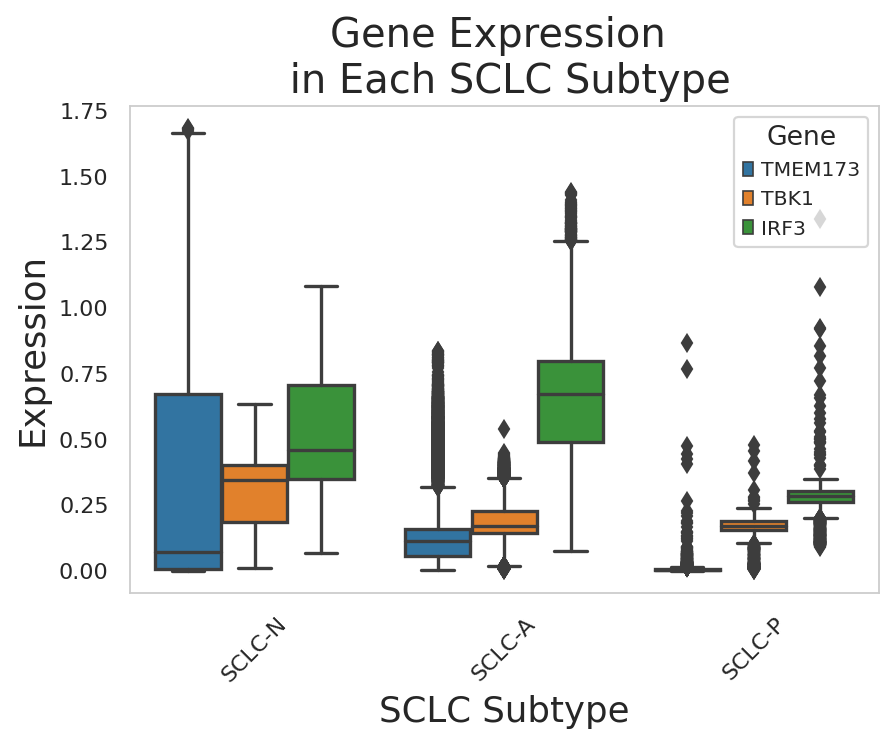

In [78]:
plt.figure(figsize=(6, 4))
sc.set_figure_params(fontsize=10)
sns.set_style("whitegrid", {'axes.grid' : False})
# Specify the genes to plot and the SCLC subtype column
genes_to_plot = ['TMEM173', 'TBK1', 'IRF3']
sclc_subtype_column = 'SCLC_subtype'

# Create a DataFrame for plotting
plot_data = pd.DataFrame(index=adata.obs.index)
for gene in genes_to_plot:
    # Extract gene expression from the imputed layer
    gene_expression = adata.layers['imputed_normalized'][:, adata.var.index.values == gene].flatten()
    plot_data[gene] = gene_expression

# Add the SCLC subtype column from adata.obs
plot_data[sclc_subtype_column] = adata.obs[sclc_subtype_column].astype(str)

# Reshape DataFrame for seaborn boxplot
plot_data = plot_data.melt(id_vars=[sclc_subtype_column], var_name='Gene', value_name='Expression')

# Plotting
sns.set_style("whitegrid", {'axes.grid' : False})
#plt.figure(figsize=(12, 8))
sns.despine()

# Create a boxplot using seaborn
sns.boxplot(x=sclc_subtype_column, y='Expression', hue='Gene', data=plot_data, palette='tab10')

# Customize plot labels and legend
plt.title('Gene Expression \n in Each SCLC Subtype', fontsize=18)
plt.xlabel('SCLC Subtype', fontsize=16)
plt.ylabel('Expression', fontsize=16)
plt.xticks(rotation=45)
plt.legend(title='Gene', loc='upper right')

# Show the plot
plt.show()


/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

<Figure size 480x480 with 0 Axes>

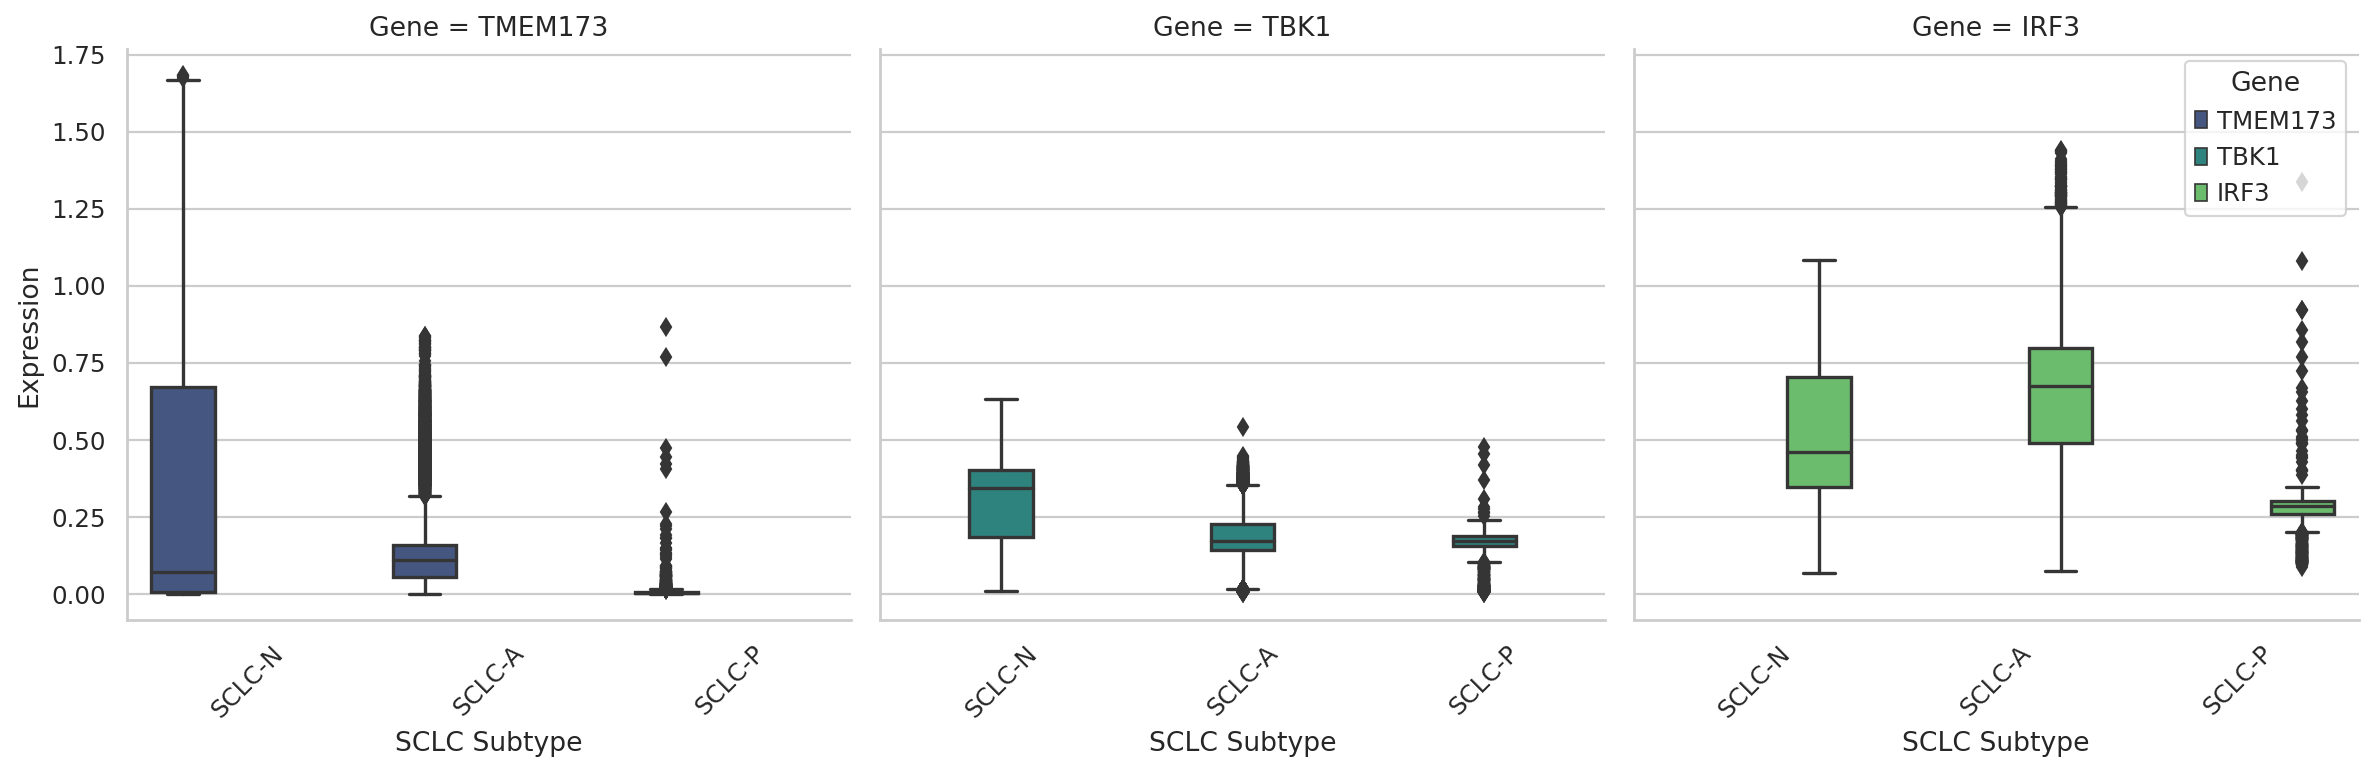

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Set the figure size and style
plt.figure(figsize=(6, 6))
sns.set(style="whitegrid")

# Specify the genes to plot and the SCLC subtype column
genes_to_plot = ['TMEM173', 'TBK1', 'IRF3']
sclc_subtype_column = 'SCLC_subtype'

# Create a DataFrame for plotting
plot_data = pd.DataFrame(index=adata.obs.index)
for gene in genes_to_plot:
    # Extract gene expression from the imputed layer
    gene_expression = adata.layers['imputed_normalized'][:, adata.var.index.values == gene].flatten()
    plot_data[gene] = gene_expression

# Add the SCLC subtype column from adata.obs
plot_data[sclc_subtype_column] = adata.obs[sclc_subtype_column].astype(str)

# Reshape DataFrame for seaborn catplot
plot_data_melted = plot_data.melt(id_vars=[sclc_subtype_column], var_name='Gene', value_name='Expression')

# Plotting with catplot
g = sns.catplot(x='SCLC_subtype', y='Expression', hue='Gene', data=plot_data_melted, kind='box',
                palette='viridis', col='Gene', margin_titles=True)

# Customize plot labels and legend
g.set_titles("{col_name}")
g.set_axis_labels('SCLC Subtype', 'Expression')
g.set_xticklabels(rotation=45)

# Set legend title using plt.legend()
plt.legend(title='Gene', loc='upper right')

# Show the plot
plt.tight_layout()  # Adjust layout to improve spacing
plt.show()


In [96]:
# Create a DataFrame for plotting
plot_data = pd.DataFrame(index=adata.obs.index)
for gene in genes_to_plot:
    # Extract gene expression from the imputed layer
    gene_expression = adata.layers['imputed_normalized'][:, adata.var.index.values == gene].flatten()
    plot_data[gene] = gene_expression

# Add the SCLC subtype column from adata.obs
plot_data[sclc_subtype_column] = adata.obs[sclc_subtype_column].astype(str)

# Reshape DataFrame for seaborn boxplot
plot_data = plot_data.melt(id_vars=[sclc_subtype_column], var_name='Gene', value_name='Expression')

In [97]:
plot_data

,SCLC_subtype,Gene,Expression
0,SCLC-N,TMEM173,0.019354
1,SCLC-A,TMEM173,0.029394
2,SCLC-N,TMEM173,0.432019
3,SCLC-P,TMEM173,0.003000
4,SCLC-N,TMEM173,1.041496
...,...,...,...
162934,SCLC-A,IRF3,0.196104
162935,SCLC-N,IRF3,0.314914
162936,SCLC-A,IRF3,0.908438
162937,SCLC-N,IRF3,0.560335


/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

<Figure size 480x480 with 0 Axes>

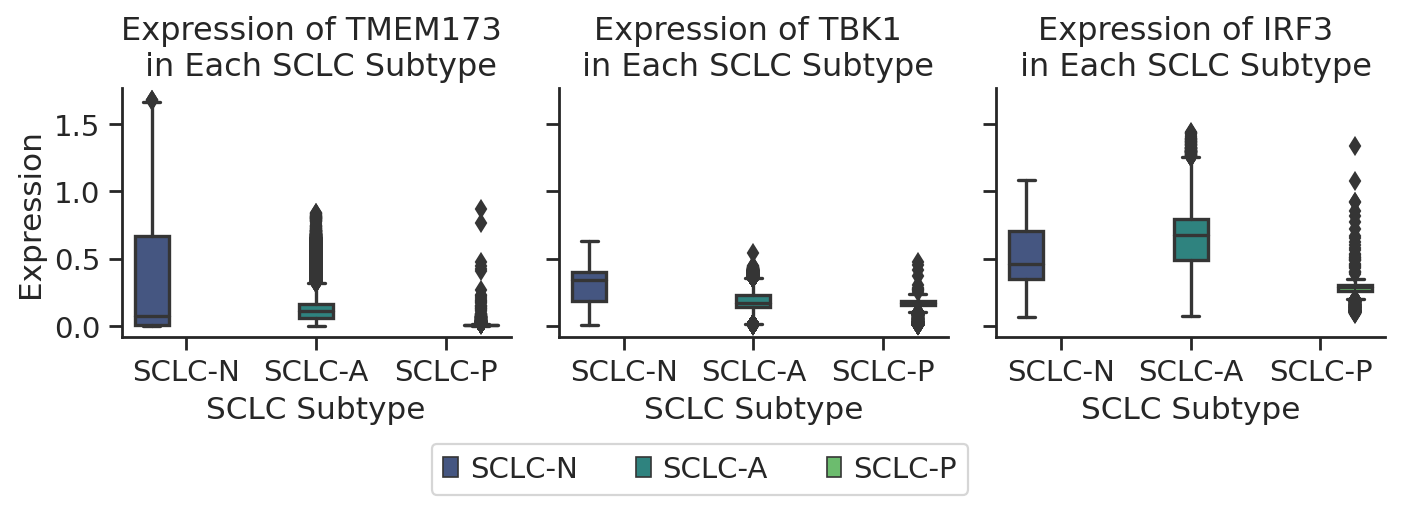

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Set figure size and style
plt.figure(figsize=(6, 6))
sns.set_context("notebook", font_scale=1.2)  # Adjust font scale

# Specify the genes to plot and the SCLC subtype column
genes_to_plot = ['TMEM173', 'TBK1', 'IRF3']
sclc_subtype_column = 'SCLC_subtype'

# Filter plot_data for the specified genes
filtered_plot_data = plot_data[plot_data['Gene'].isin(genes_to_plot)]

# Create FacetGrid for multiple plots (one per gene)
g = sns.FacetGrid(filtered_plot_data, col="Gene", col_wrap=3)
g.map_dataframe(sns.boxplot, x=sclc_subtype_column, y='Expression', hue=sclc_subtype_column, palette='viridis')

# Add single legend at the bottom center
handles, labels = g.axes.flat[0].get_legend_handles_labels()  # Get legend info from the first subplot
g.fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=len(labels))

# Set titles and labels for each subplot
g.set_titles("Expression of {col_name} \n in Each SCLC Subtype", fontsize=14)
g.set_xlabels('SCLC Subtype', fontsize=14)
g.set_ylabels('Expression', fontsize=14)

# Adjust spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()


/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

<Figure size 480x800 with 0 Axes>

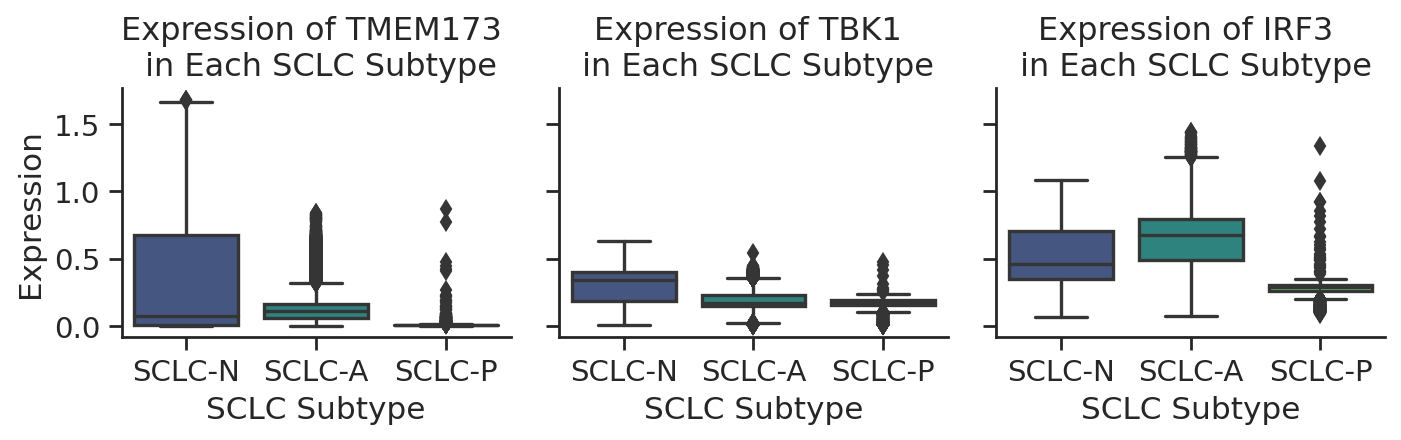

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Set figure size and style
plt.figure(figsize=(6, 10))
sns.set_context("notebook", font_scale=1.2)  # Adjust font scale

# Specify the genes to plot and the SCLC subtype column
genes_to_plot = ['TMEM173', 'TBK1', 'IRF3']
sclc_subtype_column = 'SCLC_subtype'

# Filter plot_data for the specified genes
filtered_plot_data = plot_data[plot_data['Gene'].isin(genes_to_plot)]

# Create FacetGrid for multiple plots (one per gene)
g = sns.FacetGrid(filtered_plot_data, col="Gene", col_wrap=3)
g.map_dataframe(sns.boxplot, x=sclc_subtype_column, y='Expression', palette='viridis')

# Get legend handles and labels from the first subplot
handles, labels = g.axes.flat[0].get_legend_handles_labels()

# Check if handles and labels are not empty before creating the legend
if handles and labels:
    # Add single legend at the bottom center
    g.fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=len(labels))

# Set titles and labels for each subplot
g.set_titles("Expression of {col_name} \n in Each SCLC Subtype", fontsize=14)
g.set_xlabels('SCLC Subtype', fontsize=14)
g.set_ylabels('Expression', fontsize=14)

# Adjust spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()



In [26]:
# Create a DataFrame for plotting
genes_to_plot = ['TBK1', 'IRF3']

plot_df = pd.DataFrame(index=adata.obs.index)

for gene in genes_to_plot:
    # Find the index of the gene in `adata.var.index.values`
    gene_index = np.where(adata.var.index.values == gene)[0]
    
    if len(gene_index) == 1:
        # Extract expression values for the gene using the index
        gene_expression = adata.X[:, gene_index]
        
        # Assign gene expression values to the DataFrame
        plot_df[gene] = gene_expression.flatten()
    else:
        print(f"Gene '{gene}' not found or is duplicated in adata.var.index.")

# Now `plot_df` contains expression values for the specified genes
print(plot_df.head())


                                TBK1      IRF3
Cell                                          
RU1215_192110488599350      0.000000  0.000000
RU1152_130751366121844      0.997378  0.583215
RU1231A_120703424294126     1.029073  0.000000
RU1322A_LN_133924258008493  0.708695  1.181834
RU1181B_169649541863334     0.758680  0.758680


In [43]:
# Add additional columns from concatenated_adata.obs
plot_df['SCLC_subtype'] = adata.obs['SCLC_subtype'].astype(str)
# plot_df['Culture_Media'] = concatenated_adata.obs['Culture_Media'].astype(str)
# plot_df['ZFP_Expression'] = concatenated_adata.obs['ZFP_Expression'].astype(str)

In [50]:
# Melt the DataFrame to convert SCLC subtype columns into a 'variable' column
melted_df = pd.melt(plot_df, id_vars=['Cell', 'SCLC_subtype'], var_name='Gene', value_name='Expression')

KeyError: "The following 'id_vars' are not present in the DataFrame: ['Cell']"

In [44]:
plot_df

,TBK1,IRF3,SCLC_subtype
Cell,,,
RU1215_192110488599350,0.000000,0.000000,SCLC-N
RU1152_130751366121844,0.997378,0.583215,SCLC-A
RU1231A_120703424294126,1.029073,0.000000,SCLC-N
RU1322A_LN_133924258008493,0.708695,1.181834,SCLC-P
RU1181B_169649541863334,0.758680,0.758680,SCLC-N
...,...,...,...
RU1108a_RPMI_160785132370275,0.000000,0.000000,SCLC-A
RU1293A_169220299503989,0.000000,1.834053,SCLC-N
RU1108a_Bambanker_Frozen_231897696155998,0.890860,1.437527,SCLC-A


In [48]:
# Plot box plot for each gene
for gene in genes_to_plot:
    plt.figure(figsize=(10, 6))  # Adjust figure size as needed
    
    sns.boxplot(data=plot_df[plot_df['TBK1'] == gene], 
                x='SCLC_subtype', y='Expression')
    
    plt.title(f'Expression of {gene}', fontsize=18, fontweight='bold')
    plt.xlabel('SCLC_subtype', fontsize=16)
    plt.ylabel('Gene Expression', fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    #plt.legend(title='ZFP Expression', title_fontsize='14', fontsize='12')
    plt.tight_layout()
    plt.show()


ValueError: Could not interpret input 'Expression'

<Figure size 720x432 with 0 Axes>

In [42]:
import pandas as pd

# Assuming `adata` is your AnnData object containing gene information
# Convert var_names to a DataFrame
var_names_df = pd.DataFrame({'var_names': adata.var_names})

# Define the regex pattern
pattern = 'STING'  # This pattern matches any string that starts with 'S', followed by any characters (.*), and ends with 'NG'

# Filter var_names using regex pattern
genes_with_pattern = var_names_df[var_names_df['var_names'].str.contains(pattern)]

# Print genes containing the specified pattern
print(genes_with_pattern)


Empty DataFrame
Columns: [var_names]
Index: []


In [6]:
adata = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_noreplicates/postprocess_adata/adata.combined.postprocess.h5ad')

In [7]:
adata

AnnData object with n_obs × n_vars = 29467 × 30693
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Replicate', 'Batch', 'Sample', 'phenograph', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells'
    uns: 'diffmap_evals', 'leiden', 'log1p', 'neighbors', 'num_components', 'paga', 'phenograph_sizes', 'rank_genes_groups', 'umap', 'var_explained'
    obsm: 'X_diffmap', 'X_pca', 'X_umap', 'gene_expression_encoding'
    layers: 'without_log'
    obsp: 'connectivities', 'distances'

/home/forsythb/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/forsythb/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/forsythb/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/forsythb/.local/lib

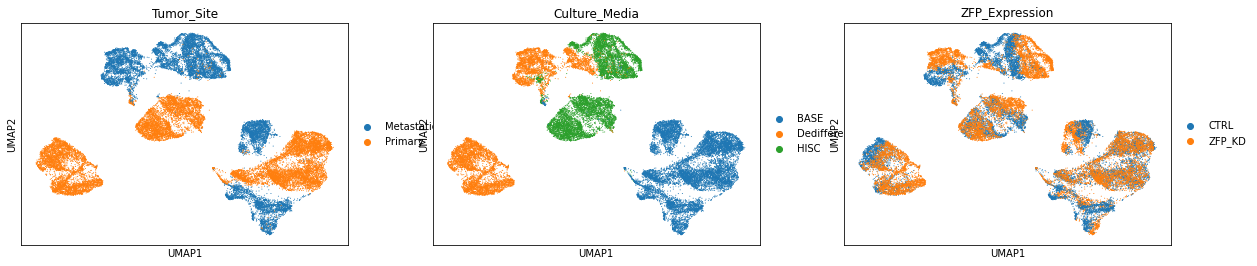

In [9]:
sc.pl.umap(adata, 
          color=['Tumor_Site', 'Culture_Media', 'ZFP_Expression'])